## 1. Import Libraries

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load Dataset

In [29]:
df = pd.read_csv("ds_salaries.csv")

## 3. Keep Required Columns

In [30]:
df = df[['experience_level','employment_type','job_title',
         'salary_in_usd','employee_residence','remote_ratio']]

## 4. Graphs (EDA)

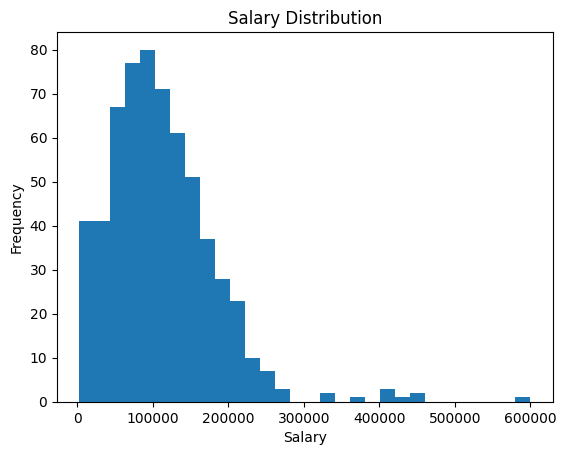

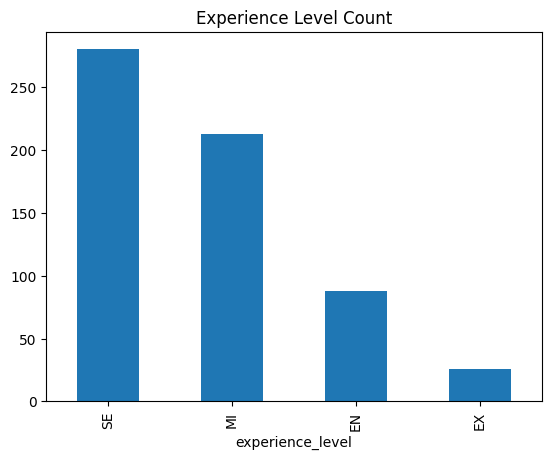

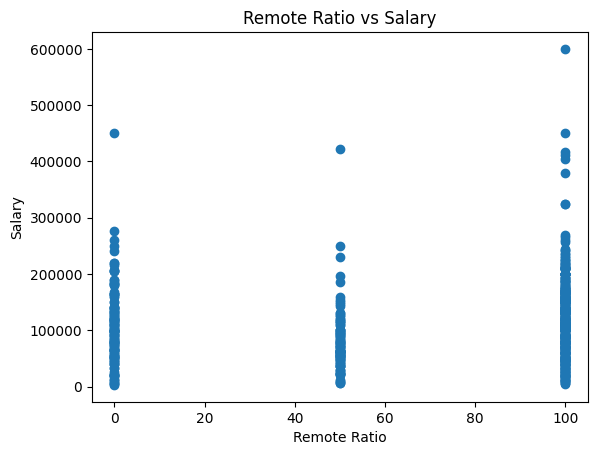

In [31]:
plt.figure()
plt.hist(df['salary_in_usd'], bins=30)
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

plt.figure()
df['experience_level'].value_counts().plot(kind='bar')
plt.title("Experience Level Count")
plt.show()

plt.figure()
plt.scatter(df['remote_ratio'], df['salary_in_usd'])
plt.title("Remote Ratio vs Salary")
plt.xlabel("Remote Ratio")
plt.ylabel("Salary")
plt.show()

## 5. Create Salary Classes

In [32]:
def label_salary(x):
    if x < 80000:
        return "Low"
    elif x < 150000:
        return "Medium"
    else:
        return "High"

df['salary_class'] = df['salary_in_usd'].apply(label_salary)

## 6. Split BEFORE encoding (FIX)

In [33]:
y_reg = df['salary_in_usd']
y_clf = df['salary_class']

X = df.drop(['salary_in_usd','salary_class'], axis=1)

# Encode only features
X = pd.get_dummies(X, drop_first=True)

# Encode labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_clf = le.fit_transform(y_clf)

## 7. Train Test Split

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

_, _, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42
)

## 8. Models

In [35]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor

lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)
log = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_reg_train)
rf.fit(X_train, y_reg_train)
log.fit(X_train, y_clf_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

## 9. Regression Evaluation

Random Forest RMSE: 42226.11190040752
Random Forest R2 Score: 0.5347652073387065


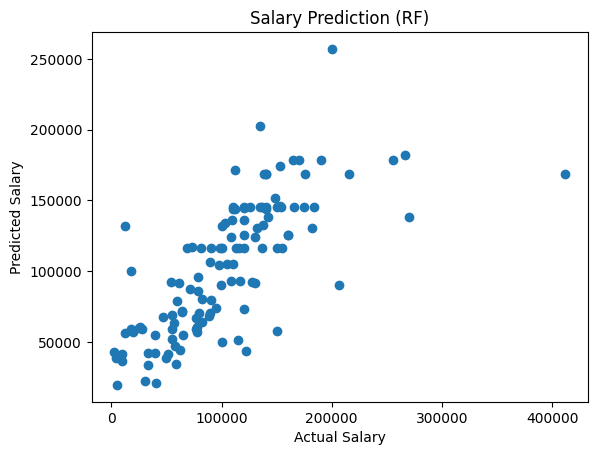

In [36]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred_rf = rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_rf))
r2 = r2_score(y_reg_test, y_pred_rf)

print("Random Forest RMSE:", rmse)
print("Random Forest R2 Score:", r2)

plt.figure()
plt.scatter(y_reg_test, y_pred_rf)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Salary Prediction (RF)")
plt.show()

## 10. Classification Evaluation

In [37]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_pred_clf = log.predict(X_test)

acc = accuracy_score(y_clf_test, y_pred_clf)
print("Classification Accuracy:", acc)

print("Confusion Matrix:")
print(confusion_matrix(y_clf_test, y_pred_clf))

Classification Accuracy: 0.6967213114754098
Confusion Matrix:
[[16  1  7]
 [ 0 38  6]
 [14  9 31]]


## 11. User Input Prediction

In [ ]:
print("\nEnter Details:")

exp = input("Experience Level (EN/MI/SE/EX): ")
emp = input("Employment Type (FT/PT/CT/FL): ")
job = input("Job Title (e.g Data Scientist): ")
res = input("Country Code (US/IN etc): ")
remote = int(input("Remote Ratio (0/50/100): "))

data = {
    'experience_level_'+exp: 1,
    'employment_type_'+emp: 1,
    'job_title_'+job: 1,
    'employee_residence_'+res: 1,
    'remote_ratio': remote
}

input_df = pd.DataFrame([data])

input_df = input_df.reindex(columns=X.columns, fill_value=0)

salary_pred = rf.predict(input_df)
class_pred = log.predict(input_df)

label = le.inverse_transform(class_pred)

print("\n💰 Predicted Salary (USD):", salary_pred[0])
print("📊 Salary Level:", label[0])